In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# **Missing Values**

In [3]:
data = {
    'LotSize': [5000, 6000, np.nan, 5500, np.nan],
    'GarageType': ['Attached', np.nan, 'Detached', 'Attached', np.nan],
    'Price': [200000, 250000, 180000, np.nan, 220000]
}
df=pd.DataFrame(data)
df

,LotSize,GarageType,Price
0,5000.0,Attached,200000.0
1,6000.0,NaN,250000.0
2,NaN,Detached,180000.0
3,5500.0,Attached,NaN
4,NaN,NaN,220000.0


**Detecting**

In [4]:
df.isnull().sum()

,0
LotSize,2
GarageType,2
Price,1


In [6]:
df.isna().sum()

,0
LotSize,2
GarageType,2
Price,1


**Ways to handle**
* Drop: how-'any'/all, subset, thresh, axis=columns
* Fill: fillna(),ffill(), bfill()
* Impute: SimpleImputer, KNNImputer

In [10]:
df.dropna()

,LotSize,GarageType,Price
0,5000.0,Attached,200000.0


In [12]:
df.dropna(thresh=2)

,LotSize,GarageType,Price
0,5000.0,Attached,200000.0
1,6000.0,NaN,250000.0
2,NaN,Detached,180000.0
3,5500.0,Attached,NaN


In [14]:
df.dropna(how='all')

,LotSize,GarageType,Price
0,5000.0,Attached,200000.0
1,6000.0,NaN,250000.0
2,NaN,Detached,180000.0
3,5500.0,Attached,NaN
4,NaN,NaN,220000.0


In [15]:
df.dropna(subset=['LotSize','Price'])

,LotSize,GarageType,Price
0,5000.0,Attached,200000.0
1,6000.0,NaN,250000.0


In [16]:
df.ffill()

,LotSize,GarageType,Price
0,5000.0,Attached,200000.0
1,6000.0,Attached,250000.0
2,6000.0,Detached,180000.0
3,5500.0,Attached,180000.0
4,5500.0,Attached,220000.0


In [17]:
df.fillna("Dummy")

,LotSize,GarageType,Price
0,5000.0,Attached,200000.0
1,6000.0,Dummy,250000.0
2,Dummy,Detached,180000.0
3,5500.0,Attached,Dummy
4,Dummy,Dummy,220000.0


In [33]:
from sklearn.impute import SimpleImputer,KNNImputer

imputer1=SimpleImputer(strategy='most_frequent')
df[['GarageTypeImputed']]=imputer1.fit_transform(df[['GarageType']])

imputer2=KNNImputer(n_neighbors=2)
df[['LotSizeImputed','PriceImputed']]=imputer2.fit_transform(df[['LotSize','Price']])

df

,LotSize,GarageType,Price,GarageTypeImputed,LotSizeImputed,PriceImputed
0,5000.0,Attached,200000.0,Attached,5000.0,200000.0
1,6000.0,NaN,250000.0,Attached,6000.0,250000.0
2,NaN,Detached,180000.0,Detached,5500.0,180000.0
3,5500.0,Attached,NaN,Attached,5500.0,225000.0
4,NaN,NaN,220000.0,Attached,5500.0,220000.0


**Input requirement:**

fit() and fit_transform() expect a 2D array‑like structure (NumPy array or DataFrame).

Even if you’re working with a single column, you must pass it as df[['col']] (double brackets) so it’s treated as 2D.

**Output:**

Both methods return a 2D NumPy array with the same number of rows and columns as the input.

# **Outlier Treatment**
* IQR
* Z-score
* Isolation Forest
* DBScan

In [34]:
np.random.seed(42)
age = np.random.normal(loc=30, scale=5, size=100)
income = np.random.normal(loc=50000, scale=8000, size=100)

age_outliers = [80, 85, 90]
income_outliers = [200000, 250000, 300000]

age = np.concatenate([age, age_outliers])
income = np.concatenate([income, income_outliers])

df = pd.DataFrame({
    'Age': age,
    'Income': income
})

df.head()


,Age,Income
0,32.483571,38677.034064
1,29.308678,46634.837418
2,33.238443,47258.283868
3,37.615149,43581.781846
4,28.829233,48709.714307


**IQR**

In [43]:
Q1=np.percentile(df['Age'],25)
Q3=np.percentile(df['Age'],75)
IQR=Q3-Q1

outliers=df[(df['Age']>Q3+1.5*IQR)|(df['Age']<Q1-1.5*IQR)]['Age']
print(Q1," ", Q3," ",IQR)
print(outliers)


27.092684452100556   32.6395686917483   5.546884239647746
74     16.901274
100    80.000000
101    85.000000
102    90.000000
Name: Age, dtype: float64


**z-score**

In [49]:
z=[(x-np.mean(df['Income']))/np.std(df['Income']) for x in df['Income']]

for i , j in enumerate(z):
  if np.abs(j)>3:
    print(df['Income'].iloc[i])

200000.0
250000.0
300000.0


**Isolation Forest**

In [54]:
from sklearn.ensemble import IsolationForest

iso_forest=IsolationForest(contamination=0.05, random_state=42)

df['flag']=iso_forest.fit_predict(df[['Age','Income']])

outliers=df[df['flag']==-1]
inliners=df[df['flag']==1]
outliers

,Age,Income,flag
13,20.433599,69705.936900,-1
74,16.901274,52213.526395,-1
79,20.062155,71761.353333,-1
100,80.000000,200000.000000,-1
101,85.000000,250000.000000,-1
102,90.000000,300000.000000,-1


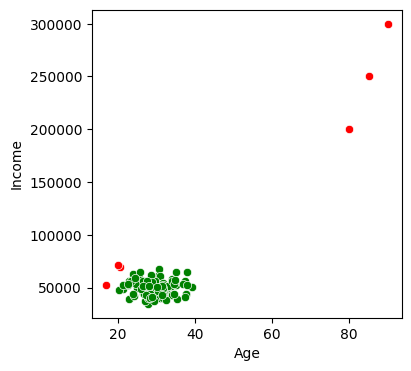

In [58]:
plt.figure(figsize=(4,4))
sns.scatterplot(data=inliners,x='Age',y='Income',color='green')
sns.scatterplot(data=outliers,x='Age',y='Income',color='red')
plt.show()

**DBSCAN**

In [70]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
scan_cluster=DBSCAN(eps=0.5, min_samples=5)

df[['Age_scaled','Income_scaled']]=scaler.fit_transform(df[['Age','Income']])
df['cluster']=scan_cluster.fit_predict(df[['Age_scaled','Income_scaled']])

outliers=df[df['cluster']==-1]
inliners=df[df['cluster']!=-1]

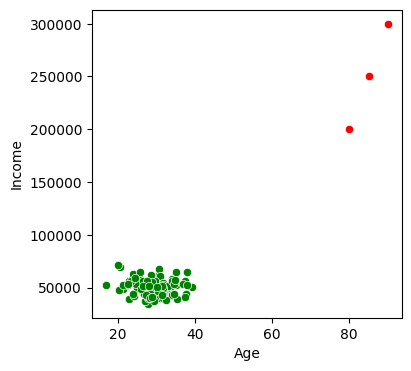

In [71]:
plt.figure(figsize=(4,4))
sns.scatterplot(data=inliners,x='Age',y='Income',color='green')
sns.scatterplot(data=outliers,x='Age',y='Income',color='red')
plt.show()

**Note:** In DBSCAN always scale the inputs so that epsion value can be set between 0-1

**Treating them**
* Cap/Winsorize
* Replacing with statistical values: mean/median etc
* Dropping
* Transformation: log, square_root, box-cox etc

In [104]:
#Winsorize age

lower_bound=Q1-1.5*IQR
lower_cap=np.percentile(df['Age'],5)

upper_bound=Q3+1.5*IQR
upper_cap=np.percentile(df['Age'],95)

df['Age_capped']=df['Age'].apply(lambda x:lower_cap if x<lower_bound else upper_cap if x>upper_bound else x)

In [105]:
#winsorize income
#Winsorize age

lower_bound=Q1-1.5*IQR
lower_cap=np.percentile(df['Income'],5)

upper_bound=Q3+1.5*IQR
upper_cap=np.percentile(df['Income'],95)

df['Income_capped']=df['Income'].apply(lambda x:lower_cap if x<lower_bound else upper_cap if x>upper_bound else x)

In [106]:
df.head()

,Age,Income,flag,cluster,Age_scaled,Income_scaled,winsorize,Age_capped,Income_capped
0,32.483571,38677.034064,1,0,0.133673,-0.493173,32.483571,32.483571,67288.714892
1,29.308678,46634.837418,1,0,-0.172588,-0.266600,29.308678,29.308678,67288.714892
2,33.238443,47258.283868,1,0,0.206490,-0.248849,33.238443,33.238443,67288.714892
3,37.615149,43581.781846,1,0,0.628682,-0.353526,37.615149,37.615149,67288.714892
4,28.829233,48709.714307,1,0,-0.218836,-0.207524,28.829233,28.829233,67288.714892


In [109]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
cluster=DBSCAN(eps=0.5, min_samples=5)
scaler=StandardScaler()

df[['Age_scaled']]=scaler.fit_transform(df[['Age_capped']])
df[['Income_scaled']]=scaler.fit_transform(df[['Income_capped']])

df['result']=cluster.fit_predict(df[['Age_scaled','Income_scaled']])


outliers=df[df['result']==-1]
inliners=df[df['result']!=-1]

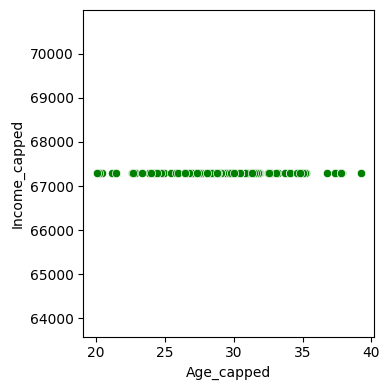

In [111]:
plt.figure(figsize=(4,4))

sns.scatterplot(data=outliers,x='Age_capped',y='Income_capped',color='red')
sns.scatterplot(data=inliners,x='Age_capped',y='Income_capped',color='green')
plt.tight_layout()

# **Train Test Split**

In [114]:
data=sns.load_dataset('iris')
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [128]:
from sklearn.model_selection import train_test_split

# splitting the data into temp(train+validation) and test
X_temp, X_test, y_temp, y_test= train_test_split(data.drop('species',axis=1),data['species'], test_size=0.2,random_state=42, stratify=data['species'])

#splitting temp data into trian and validaiotn
X_train,X_val, y_train,y_val= train_test_split(X_temp,y_temp, test_size=0.1,random_state=42, stratify=y_temp)


In [129]:
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(108, 4)
(30, 4)
(12, 4)


# **Feature Scaling**

* Standard
* Min-Max
* Robust

In [130]:
df = pd.DataFrame({
    'Age': np.random.randint(18, 60, 10),
    'Income': np.random.randint(20000, 100000, 10)
})
df

,Age,Income
0,19,70993
1,43,49592
2,34,30647
3,57,28716
4,50,90316
5,26,22368
6,56,97575
7,46,26655
8,59,90031
9,43,96429


In [133]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

scaler1=StandardScaler()
scaler2=MinMaxScaler()
scaler3=RobustScaler()

df[['Age_scaled']]=scaler1.fit_transform(df[['Age']])
df[['Income_scaled']]=scaler2.fit_transform(df[['Income']])
df[['Age_scaled_robust']]=scaler3.fit_transform(df[['Age']])
df[['Income_scaled_robust']]=scaler3.fit_transform(df[['Income']])

df.head()

,Age,Income,Age_scaled,Income_scaled,Age_scaled_robust,Income_scaled_robust
0,19,70993,-1.906777,0.646549,-1.397260,0.175286
1,43,49592,-0.023540,0.361988,-0.082192,-0.175286
2,34,30647,-0.729754,0.110083,-0.575342,-0.485626
3,57,28716,1.075014,0.084407,0.684932,-0.517257
4,50,90316,0.525737,0.903480,0.301370,0.491818


# **Feature Encoding**

* Ordinal: Always specify categories
* Label: For output
* OneHot: Gives a matrix-->convert to array-->extract features -->convert to df
* Target
* Fequency

In [136]:
df = pd.DataFrame({
    'Education': ['High School', 'Bachelor', 'Master', 'PhD', 'Bachelor'],
    'City': ['Delhi', 'Mumbai', 'Delhi', 'Bengaluru', 'Chennai'],
    'Target': [1, 0, 1, 0, 1]
})
df.head()

,Education,City,Target
0,High School,Delhi,1
1,Bachelor,Mumbai,0
2,Master,Delhi,1
3,PhD,Bengaluru,0
4,Bachelor,Chennai,1


In [142]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder

encoder1=OrdinalEncoder(categories=[['High School','Bachelor','Master','PhD']])
df[['Education_encoded']]=encoder1.fit_transform(df[['Education']])

In [146]:
df.head()

,Education,City,Target,Education_encoded
0,High School,Delhi,1,0.0
1,Bachelor,Mumbai,0,1.0
2,Master,Delhi,1,2.0
3,PhD,Bengaluru,0,3.0
4,Bachelor,Chennai,1,1.0


In [148]:
df['City'].value_counts()

,count
City,
Delhi,2
Mumbai,1
Bengaluru,1
Chennai,1


In [164]:
encoder2=OneHotEncoder(handle_unknown='ignore')
city_encoded=encoder2.fit_transform(df[['City']])
city_encoded_df = pd.DataFrame(city_encoded.toarray(),
                               columns=encoder2.get_feature_names_out(['City']))

# Concatenate with original DataFrame
df = pd.concat([df, city_encoded_df], axis=1)

In [165]:
df.head()

,Education,City,Target,Education_encoded,City_Bengaluru,City_Chennai,City_Delhi,City_Mumbai,City_Bengaluru,City_Chennai,City_Delhi,City_Mumbai
0,High School,Delhi,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,Bachelor,Mumbai,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,Master,Delhi,1,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,PhD,Bengaluru,0,3.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,Bachelor,Chennai,1,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


**features with high cardinality**

In [167]:
#Target_encoding

data=df[['Education','City','Target']]

target_mean=df.groupby('City')['Target'].mean()

In [168]:
target_mean

,Target
City,
Bengaluru,0.0
Chennai,1.0
Delhi,1.0
Mumbai,0.0


In [171]:
data['City_target_encoded']=data['City'].map(target_mean)
data.head()

,Education,City,Target,City_target_encoded
0,High School,Delhi,1,1.0
1,Bachelor,Mumbai,0,0.0
2,Master,Delhi,1,1.0
3,PhD,Bengaluru,0,0.0
4,Bachelor,Chennai,1,1.0


In [173]:
#Frequence encoding

freq_count=df['City'].value_counts()
data['City_freq_encoded']=data['City'].map(freq_count)
data.head()

,Education,City,Target,City_target_encoded,City_freq_encoded
0,High School,Delhi,1,1.0,2
1,Bachelor,Mumbai,0,0.0,1
2,Master,Delhi,1,1.0,2
3,PhD,Bengaluru,0,0.0,1
4,Bachelor,Chennai,1,1.0,1


# **Transformation**

* Log
* Square, cube etc
* Square Root
* Box-Cox : Normalization(Only positive values allowed)
* Yeo-Johnson: Normalizaion(With 0 and negative values present)

In [176]:
# Synthetic skewed dataset
np.random.seed(42)
df = pd.DataFrame({
    'Sales': np.random.exponential(scale=1000, size=10)  # right-skewed data
})

In [180]:
from scipy.stats import skew,shapiro

print("Skewness coeff", skew(df))

shapiro_stats, p_value=shapiro(df)
print("Shapiro-statistics", shapiro_stats)
print("P-value", p_value)

Skewness coeff [0.94122598]
Shapiro-statistics 0.8959092481620066
P-value 0.19745199257133528


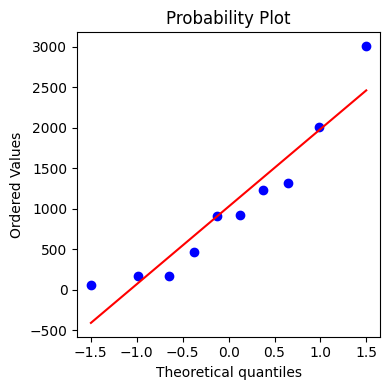

In [188]:
from scipy import stats
plt.figure(figsize=(4,4))
stats.probplot(df['Sales'],dist='norm', plot=plt)
plt.tight_layout()

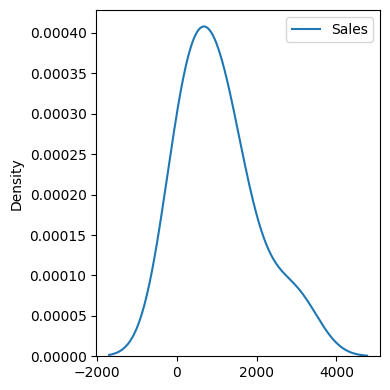

In [177]:
plt.figure(figsize=(4,4))
sns.kdeplot(data=df)
plt.tight_layout()

**Log transformation**

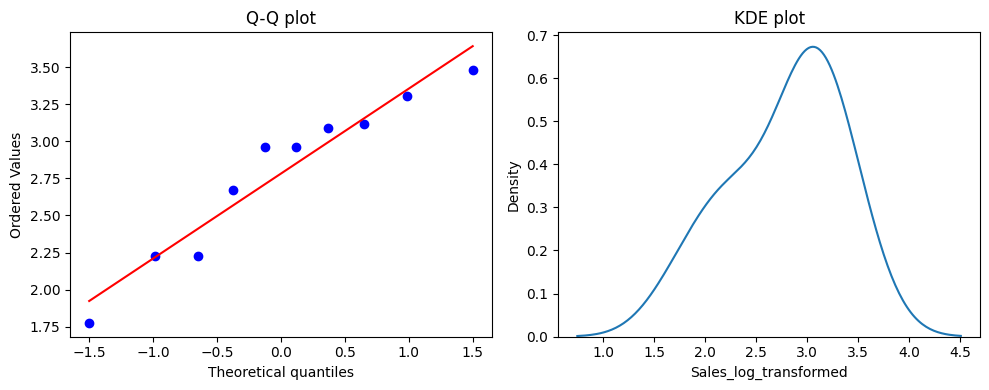

In [200]:
df['Sales_log_transformed']=np.log10(df['Sales']) #log to the base 10

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
stats.probplot(df['Sales_log_transformed'], dist='norm',plot=axes[0])
axes[0].set_title('Q-Q plot')

sns.kdeplot(df['Sales_log_transformed'])
axes[1].set_title('KDE plot')
plt.tight_layout()
plt.show()

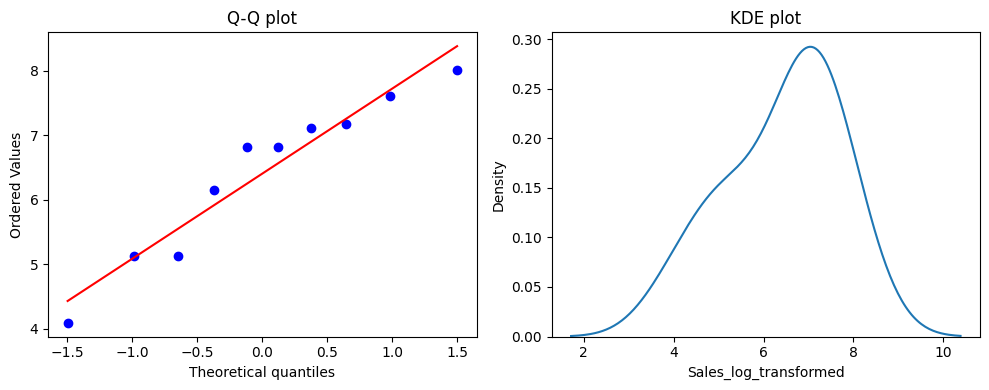

In [201]:
df['Sales_log_transformed']=np.log(df['Sales']) #Natural log

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
stats.probplot(df['Sales_log_transformed'], dist='norm',plot=axes[0])
axes[0].set_title('Q-Q plot')

sns.kdeplot(df['Sales_log_transformed'])
axes[1].set_title('KDE plot')
plt.tight_layout()
plt.show()

np.log(x) → natural log (base e).

np.log10(x) → log base 10.

Mathematically, they differ only by a constant scaling factor:

log10(𝑥)=ln(𝑥)/ln(10)

So every value in np.log10() is just a rescaled version of np.log().

In [203]:
df['sales_cube']=np.power(df['Sales'],3)
df[['Sales','sales_cube']].head()

,Sales,sales_cube
0,469.268090,1.033387e+08
1,3010.121431,2.727420e+10
2,1316.745694,2.282999e+09
3,912.942554,7.609048e+08
4,169.624870,4.880548e+06


<Axes: xlabel='sales_cube', ylabel='Density'>

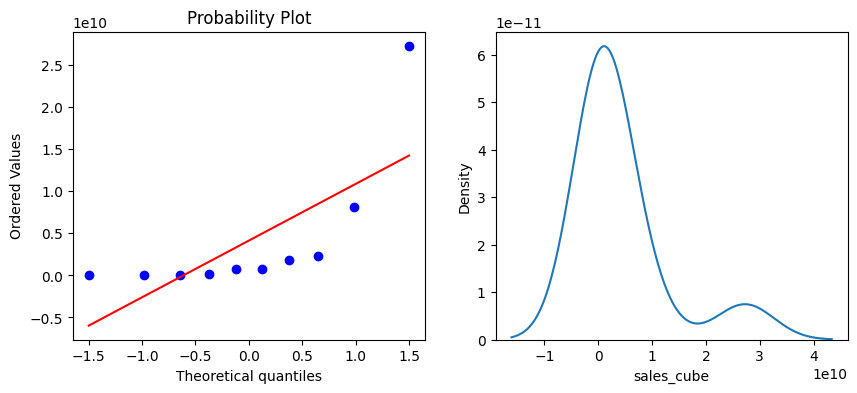

In [206]:
figure,axes=plt.subplots(1,2,figsize=(10,4))

stats.probplot(df['sales_cube'],dist='norm',plot=axes[0])

sns.kdeplot(df['sales_cube'])

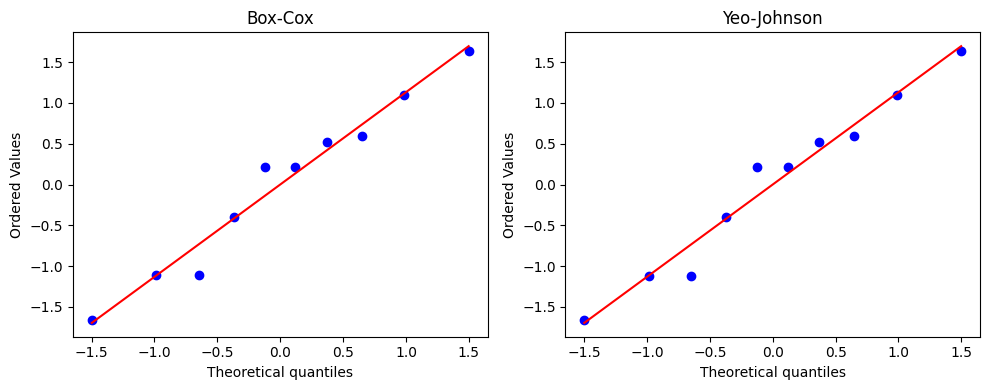

In [208]:
from sklearn.preprocessing import PowerTransformer

trans_box_cox= PowerTransformer(method='box-cox')
trans_yeo_johnson= PowerTransformer(method='yeo-johnson')

df[['sales_box_cox']]=trans_box_cox.fit_transform(df[['Sales']])
df[['sales_yeo_johnson']]=trans_yeo_johnson.fit_transform(df[['Sales']])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
stats.probplot(df['sales_box_cox'], dist='norm',plot=axes[0])
axes[0].set_title('Box-Cox')

stats.probplot(df['sales_yeo_johnson'], dist='norm',plot=axes[1])
axes[1].set_title('Yeo-Johnson')
plt.tight_layout()

# **Feature Selection**

**Filter methods**
* Variance threshold
* corr
* ANOVA, Chi-square

**Wrapper methods**
* Back elimination
* Forward selection

**Wrapper methods**
* Lasso regularization
* ElasticNet regularization
* Tree based methods

In [3]:
np.random.seed(42)
df = pd.DataFrame({
    'Feature1': np.random.randint(0, 2, 20),   # low variance
    'Feature2': np.random.normal(10, 1, 20),   # numeric
    'Feature3': np.random.normal(20, 5, 20),   # numeric
    'Feature4': np.random.choice(['A','B','C'], 20),  # categorical
    'Target': np.random.choice([0,1], 20)      # binary target
})

df.head()

,Feature1,Feature2,Feature3,Feature4,Target
0,0,9.530526,16.996807,A,0
1,1,10.542560,18.541531,A,1
2,0,9.536582,16.991467,A,0
3,0,9.534270,29.261391,C,1
4,0,10.241962,19.932514,A,0


**Variance Threshold**

In [4]:
from sklearn.feature_selection import VarianceThreshold, f_classif, chi2

var_thresh=VarianceThreshold(threshold=0.3)
var_thresh.fit(df[['Feature1','Feature2','Feature3']])
var_thresh.get_support()

array([False,  True,  True])

<Axes: >

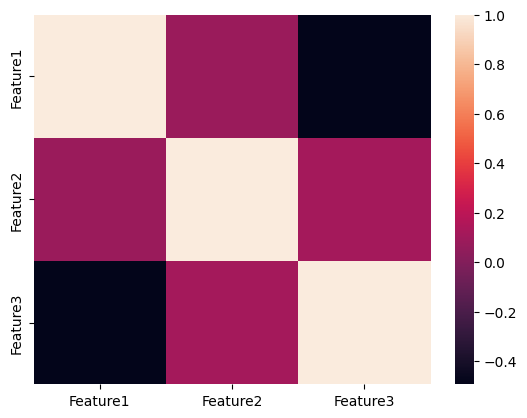

In [9]:
corr_matrix=df[['Feature1','Feature2','Feature3']].corr()
sns.heatmap(corr_matrix)

In [14]:
df[['Feature1','Feature3']].corr()

,Feature1,Feature3
Feature1,1.000000,-0.494205
Feature3,-0.494205,1.000000


**ANOVA**

In [15]:
from sklearn.feature_selection import SelectKBest

selector=SelectKBest(score_func=f_classif, k=2)
selector.fit(df[['Feature1','Feature2','Feature3']],df['Target'])
selector.get_support()

array([ True, False,  True])

**Chi-Square**

In [16]:
selector2=SelectKBest(score_func=chi2, k=2)
selector2.fit(df[['Feature1','Feature2','Feature3']],df['Target'])
selector2.get_support()

array([ True, False,  True])

**Lasso**

In [20]:
from sklearn.linear_model import Lasso

lasso=Lasso(alpha=0.1)
lasso.fit(df[['Feature1','Feature2','Feature3']],df['Target'])
lasso.coef_

array([ 0.        , -0.        ,  0.02865416])

**ElasticNet**

In [21]:
from sklearn.linear_model import ElasticNet


elastic=ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(df[['Feature1','Feature2','Feature3']],df['Target'])
elastic.coef_

array([ 0.        , -0.        ,  0.03098596])

In [23]:
#Trying out ridge

from sklearn.linear_model import Ridge

ridge=Ridge(alpha=0.1)
ridge.fit(df[['Feature1','Feature2','Feature3']],df['Target'])
ridge.coef_

#It shrinks the coefficient but never touches to 0

array([ 0.2561787 , -0.03498962,  0.04742258])

**Tree Based**

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

tree=DecisionTreeClassifier(max_depth=3)
tree.fit(df[['Feature1','Feature2','Feature3']],df['Target'])
print("Decision tree",tree.feature_importances_)

rf=RandomForestClassifier(n_estimators=100, max_depth=3)
rf.fit(df[['Feature1','Feature2','Feature3']],df['Target'])
print("Random Forest",rf.feature_importances_)

Decision tree [0.         0.71972318 0.28027682]
Random Forest [0.06567186 0.45130722 0.48302091]


# **Visualizing Trees**

In [41]:
data=sns.load_dataset('iris')
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [35]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_train,X_test, y_train, y_test=train_test_split(data.drop('species',axis=1),data['species'])

tree=DecisionTreeClassifier(max_depth=3)
tree.fit(X_train,y_train)

y_pred=tree.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.73      0.92      0.81        12
   virginica       0.92      0.75      0.83        16

    accuracy                           0.87        38
   macro avg       0.89      0.89      0.88        38
weighted avg       0.88      0.87      0.87        38



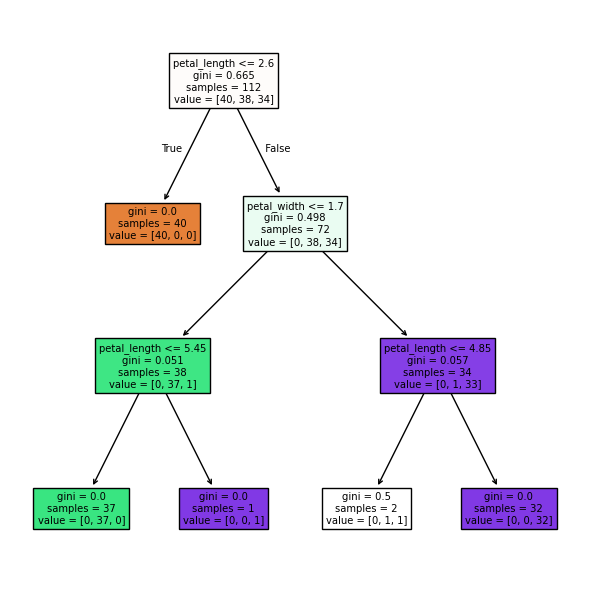

In [46]:
plt.figure(figsize=(6,6))
plot_tree(tree,feature_names=data.columns, filled=True)
plt.tight_layout()

In [47]:
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier

rf=RandomForestClassifier(n_estimators=100, max_depth=3)
rf.fit(X_train,y_train)

y_pred=rf.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.73      0.92      0.81        12
   virginica       0.92      0.75      0.83        16

    accuracy                           0.87        38
   macro avg       0.89      0.89      0.88        38
weighted avg       0.88      0.87      0.87        38



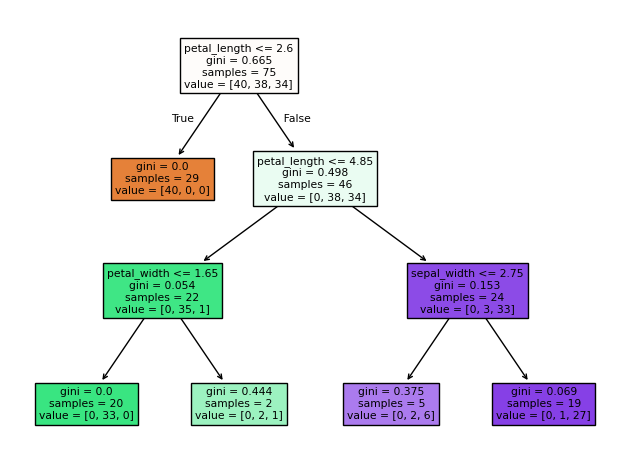

In [50]:
plot_tree(rf.estimators_[0],feature_names=data.columns, filled=True)
plt.tight_layout()

**Handling Imbalance in data**

* For oversampling: RandomOverSampling, SMOTE
* For undersampling: RandomUnderSampling

In [61]:
from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Synthetic imbalanced dataset
X, y = make_classification(n_samples=200, n_features=5, n_classes=2,
                           weights=[0.9, 0.1], random_state=42)

print("Original class distribution:", pd.Series(y).value_counts())

#  Random Oversampling
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X, y)
print("\nAfter Random Oversampling:", pd.Series(y_ros).value_counts())

# Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X, y)
print("\nAfter Random Undersampling:", pd.Series(y_rus).value_counts())

# SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)
print("\nAfter SMOTE:", pd.Series(y_smote).value_counts())


Original class distribution: 0    179
1     21
Name: count, dtype: int64

After Random Oversampling: 0    179
1    179
Name: count, dtype: int64

After Random Undersampling: 0    21
1    21
Name: count, dtype: int64

After SMOTE: 0    179
1    179
Name: count, dtype: int64


# **Fit Vs Transform Vs Predict**
* Fit learns parameters from data
* Transform applies the learning to the data
* To use a trained model to make predictions on new data

**Usage**
* Use 'fit' only on train data
* Use 'transform' on train as well as test data but the learned parameters should come from train data only
* fit_transform only on train data
* fit on test data
* fit_predict only on clustering

📌 Key Takeaway

Train: fit or fit_transform

Test: transform + predict

Clustering: fit_predict

# **Numerical Encoding**

Binning: Converts continuous values into discrete intervals (bins).

Binarization: Converts numerical values into binary (0/1) based on a threshold.

In [62]:
# Synthetic dataset
np.random.seed(42)
df = pd.DataFrame({'Age': np.random.randint(18, 70, 10)})

print("Original Data:\n", df)

# Binning Age into categories
bins = [0, 25, 40, 60, 100]
labels = ['Youth', 'Adult', 'Middle-Aged', 'Senior']
df['Age_binned'] = pd.cut(df['Age'], bins=bins, labels=labels)

print("\nAfter Binning:\n", df)


Original Data:
    Age
0   56
1   69
2   46
3   32
4   60
5   25
6   38
7   56
8   36
9   40

After Binning:
    Age   Age_binned
0   56  Middle-Aged
1   69       Senior
2   46  Middle-Aged
3   32        Adult
4   60  Middle-Aged
5   25        Youth
6   38        Adult
7   56  Middle-Aged
8   36        Adult
9   40        Adult


In [63]:
from sklearn.preprocessing import Binarizer

# Synthetic dataset
df = pd.DataFrame({'Income': [20000, 35000, 50000, 75000, 100000]})
print("Original Data:\n", df)

# Binarize Income with threshold = 50000
binarizer = Binarizer(threshold=50000)
df['Income_binary'] = binarizer.fit_transform(df[['Income']])

print("\nAfter Binarization:\n", df)


Original Data:
    Income
0   20000
1   35000
2   50000
3   75000
4  100000

After Binarization:
    Income  Income_binary
0   20000              0
1   35000              0
2   50000              0
3   75000              1
4  100000              1


# **Column Transformer and Pipeline**

ColumnTransformer → Applies different preprocessing steps to different columns.

Pipeline → Chains preprocessing and model training together so the same steps are automatically applied during training and prediction.

**Load Data**

In [77]:
from sklearn.datasets import load_iris

iris=load_iris()
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df.head()



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [78]:
df['species']=iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [79]:
#Since there are not categorical features in this data , hence creating one from sepal_length

df['size']=pd.cut(
    df['sepal length (cm)'],
    bins=[0,2,4,6],
    labels=['small','medium','large']
)

In [80]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,size
0,5.1,3.5,1.4,0.2,0,large
1,4.9,3.0,1.4,0.2,0,large
2,4.7,3.2,1.3,0.2,0,large
3,4.6,3.1,1.5,0.2,0,large
4,5.0,3.6,1.4,0.2,0,large


**Define features and target**

In [83]:
X=df.drop('species',axis=1)
y=df['species']

**Train-Test-Split**

In [84]:
from sklearn.model_selection import train_test_split

X_train,X_test, y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42)

**Separate numerical and categorical features**

In [99]:
num_cols=['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']
cat_cols=['size']

**Create functions for non defined functions**

In [121]:
from sklearn.base import BaseEstimator, TransformerMixin
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X.copy())
        for col in X.columns:
            q1 = X[col].quantile(0.25)
            q3 = X[col].quantile(0.75)
            iqr = q3 - q1
            lower = q1 - self.factor * iqr
            upper = q3 + self.factor * iqr
            X[col] = X[col].clip(lower, upper)
        return X

**Create ColumnTransformer**

In [122]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor=ColumnTransformer(transformers=[
    ('num',StandardScaler(),num_cols),
    ('cat',OneHotEncoder(),cat_cols)
])

**Pipeline**

In [123]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

pipe=Pipeline([
    ('preprocessor',preprocessor),
    ('outlier_capper',OutlierCapper()),
    ('classifier',DecisionTreeClassifier())
])

In [124]:
pipe.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['sepal length (cm)',
                                                   'sepal width (cm)',
                                                   'petal length (cm)',
                                                   'petal width (cm)']),
                                                 ('cat', OneHotEncoder(),
                                                  ['size'])])),
                ('outlier_capper', OutlierCapper()),
                ('classifier', DecisionTreeClassifier())])

In [125]:
y_pred=pipe.predict(X_test)

In [126]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



**Pickle**

In [127]:
import pickle

with open('pipe.pkl','wb') as f:
    pickle.dump(pipe,f)

In [129]:
#load
with open('pipe.pkl','rb') as f:
  model=pickle.load(f)

In [131]:
y_predict=model.predict(X_test)

#Predict directly from the loaded pickle file